# 02_cleaning_preprocessing - Làm sạch và tiền xử lý dữ liệu Digital Burnout

Notebook này thực hiện bước **Cleaning & Preprocessing** cho dataset:

`digital_burnout_productivity_dataset_5M.csv`

Mục tiêu:
- Loại bỏ dữ liệu trùng lặp.
- Kiểm tra và xử lý missing values.
- Kiểm tra kiểu dữ liệu.
- Phân tích outlier bằng phương pháp IQR.
- Mã hóa biến phân loại.
- Chọn các thuộc tính nghiên cứu.
- Chuẩn hóa dữ liệu bằng StandardScaler.
- Lưu dataset đã xử lý.

Notebook này **không thực hiện**:
- Feature Engineering
- Machine Learning
- Phân tích chuyên sâu

## Import thư viện

In [30]:
import os
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", None)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Load Dataset

Đọc dữ liệu và kiểm tra nhanh kích thước Dataset

In [31]:
file_path = "../data/raw/digital_burnout_productivity_dataset_5M.csv"

df = pd.read_csv(file_path)

print("Dataset đã được tải thành công.")
print(f"Số dòng: {df.shape[0]:,}")
print(f"Số cột : {df.shape[1]}")

display(df.head())

Dataset đã được tải thành công.
Số dòng: 5,000,000
Số cột : 34


,user_id,age,occupation,work_mode,device_usage_type,daily_screen_time,social_media_hours,doomscrolling_duration,app_switch_frequency,notification_count,smartphone_unlocks,late_night_device_usage,focus_sessions,deep_work_hours,distraction_frequency,task_completion_rate,concentration_score,sleep_hours,sleep_quality,caffeine_intake,physical_activity,stress_level,workspace_quality,meeting_hours,internet_stability,remote_work_days,motivation_level,mental_fatigue,emotional_exhaustion,work_satisfaction,mental_state,burnout_risk,productivity_score,productivity_category
0,1,56,Content Creator,Office,Entertainment-Centric,8.8,5.0,1.2,41,112,49,1,3,6.0,67,92,2,5.9,10,6,1.6,10,5,2.8,3,4,8.0,10,4,8,Balanced,46,100,High
1,2,46,Student,Hybrid,Work-Centric,10.3,2.2,2.4,119,168,153,1,9,4.6,75,74,3,5.6,7,5,1.1,5,10,3.2,7,6,5.0,7,9,7,Balanced,57,96,High
2,3,32,Software Engineer,Remote,Balanced,6.5,4.6,1.0,121,199,234,1,5,NaN,70,96,7,5.5,8,6,1.1,4,1,2.3,9,6,8.0,5,2,6,Balanced,29,79,High
3,4,25,Designer,Office,Balanced,9.6,1.2,0.1,85,122,177,1,9,2.9,107,60,3,6.1,5,1,1.7,1,4,3.8,10,5,6.0,4,5,3,Burnout,57,63,Medium
4,5,38,Analyst,Hybrid,Work-Centric,13.3,1.6,1.9,221,73,91,1,9,2.8,72,73,9,7.9,1,3,1.8,4,8,3.0,1,1,4.0,7,9,7,Focused,64,89,High


## Khai báo các thuộc tính nghiên cứu

Danh sách thuộc tính nghiên cứu được xác định dựa trên căn cứ học thuật của đề tài Digital Burnout.

Các biến này sẽ được giữ lại ở bước Feature Selection, sau khi hoàn tất kiểm tra và xử lý dữ liệu cơ bản.

In [32]:
research_features = [
    "emotional_exhaustion",
    "stress_level",
    "mental_fatigue",
    
    "daily_screen_time",
    "social_media_hours",
    "doomscrolling_duration",
    "late_night_device_usage",
    "notification_count",
    "smartphone_unlocks",
    "app_switch_frequency",
    
    "concentration_score",
    "distraction_frequency",
    "focus_sessions",
    "deep_work_hours",
    "task_completion_rate",
    "motivation_level",
    
    "sleep_hours",
    "sleep_quality",
    
    "work_mode",
    "device_usage_type",

    # target
    "burnout_risk",
    "productivity_score"
]

missing_research_features = [col for col in research_features if col not in df.columns]

print("Số thuộc tính nghiên cứu:", len(research_features))

if missing_research_features:
    print("Các thuộc tính nghiên cứu không có trong dataset:")
    print(missing_research_features)
else:
    print("Tất cả thuộc tính nghiên cứu đều có trong dataset.")

Số thuộc tính nghiên cứu: 22
Tất cả thuộc tính nghiên cứu đều có trong dataset.


## Remove Duplicates

Dữ liệu trùng lặp có thể làm sai lệch thống kê mô tả và ảnh hưởng đến các bước phân tích sau này.

Ở bước này:
- Kiểm tra số dòng trùng lặp hoàn toàn.
- Loại bỏ các dòng trùng lặp nếu có.

In [33]:
duplicate_count_before = df.duplicated().sum()
duplicate_percent_before = duplicate_count_before / len(df) * 100

print("Trước xử lý:")
print(f"Số dòng trùng lặp: {duplicate_count_before:,}")
print(f"Tỷ lệ trùng lặp: {duplicate_percent_before:.4f}%")

df = df.drop_duplicates().reset_index(drop=True)
duplicate_count_after = df.duplicated().sum()

print("Sau xử lý:")
print(f"Số dòng còn lại: {df.shape[0]:,}")
print(f"Số dòng trùng lặp còn lại: {duplicate_count_after:,}")

Trước xử lý:
Số dòng trùng lặp: 0
Tỷ lệ trùng lặp: 0.0000%
Sau xử lý:
Số dòng còn lại: 5,000,000
Số dòng trùng lặp còn lại: 0


## Missing Values Handling

Nguyên tắc xử lý:
- Biến định lượng: điền bằng **median** để giảm ảnh hưởng của outlier.
- Biến phân loại: điền bằng **mode** vì đây là giá trị xuất hiện phổ biến nhất.

Notebook này chỉ xử lý missing values ở mức cơ bản, chưa thực hiện suy luận nâng cao hoặc mô hình hóa dữ liệu thiếu.

In [34]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Số biến định lượng:", len(numerical_columns))
print("Số biến phân loại:", len(categorical_columns))

missing_before = df.isnull().sum()

missing_before = missing_before[
    missing_before > 0
].sort_values(ascending=False)

display(
    missing_before.to_frame(
        name="missing_count"
    )
)

Số biến định lượng: 29
Số biến phân loại: 5


,missing_count
social_media_hours,100000
deep_work_hours,100000
sleep_hours,100000
motivation_level,100000


In [35]:
# Numerical
for col in numerical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Categorical
for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Đã xử lý missing values.")

missing_after = df.isnull().sum().sum()
print(f"Số missing values còn lại: {missing_after:,}")

Đã xử lý missing values.
Số missing values còn lại: 0


## Data Type Validation

Bước này kiểm tra kiểu dữ liệu của các biến nghiên cứu.

Các biến nghiên cứu phần lớn là biến định lượng, ngoại trừ:
- `work_mode`
- `device_usage_type`

Nếu các biến định lượng bị đọc sai kiểu dữ liệu, notebook sẽ chuyển đổi sang dạng numeric.

In [36]:
target_categorical_columns = [
    "work_mode",
    "device_usage_type"
]

target_numerical_columns = [
    col for col in research_features
    if col not in target_categorical_columns
]

data_type_validation = pd.DataFrame({
    "column_name": research_features,
    "current_dtype": [df[col].dtype if col in df.columns else "missing" for col in research_features]
})

display(data_type_validation)

,column_name,current_dtype
0,emotional_exhaustion,int64
1,stress_level,int64
2,mental_fatigue,int64
3,daily_screen_time,float64
4,social_media_hours,float64
5,doomscrolling_duration,float64
6,late_night_device_usage,int64
7,notification_count,int64
8,smartphone_unlocks,int64
9,app_switch_frequency,int64


In [37]:
for col in target_numerical_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

for col in target_categorical_columns:
    if col in df.columns:
        df[col] = df[col].astype("category")

print("Đã kiểm tra và chuyển đổi kiểu dữ liệu cho các biến nghiên cứu.")

data_type_after = pd.DataFrame({
    "column_name": research_features,
    "dtype_after": [df[col].dtype if col in df.columns else "missing" for col in research_features]
})

display(data_type_after)

Đã kiểm tra và chuyển đổi kiểu dữ liệu cho các biến nghiên cứu.


,column_name,dtype_after
0,emotional_exhaustion,int64
1,stress_level,int64
2,mental_fatigue,int64
3,daily_screen_time,float64
4,social_media_hours,float64
5,doomscrolling_duration,float64
6,late_night_device_usage,int64
7,notification_count,int64
8,smartphone_unlocks,int64
9,app_switch_frequency,int64


## Outlier Analysis bằng IQR

Phương pháp IQR được sử dụng để phát hiện giá trị ngoại lệ ở các biến định lượng.

Công thức:
- Q1 = phân vị 25%
- Q3 = phân vị 75%
- IQR = Q3 - Q1
- Lower Bound = Q1 - 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR

Notebook này **chỉ báo cáo outlier**, không tự động xóa vì cần có căn cứ học thuật hoặc nghiệp vụ trước khi loại bỏ dữ liệu.

In [38]:
outlier_reports = []

for col in target_numerical_columns:
    if col in df.columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        outlier_percent = outlier_count / len(df) * 100
        
        outlier_reports.append({
            "column_name": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": outlier_count,
            "outlier_percent": outlier_percent
        })

outlier_report_df = pd.DataFrame(outlier_reports)
outlier_report_df = outlier_report_df.sort_values(
    by="outlier_percent",
    ascending=False
)

display(outlier_report_df)

,column_name,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percent
3,daily_screen_time,6.3,9.7,3.4,1.2,14.8,34754,0.69508
13,deep_work_hours,1.8,4.2,2.4,-1.8,7.8,17362,0.34724
4,social_media_hours,2.3,4.7,2.4,-1.3,8.3,17325,0.34650
5,doomscrolling_duration,1.0,2.6,1.6,-1.4,5.0,16924,0.33848
19,productivity_score,56.0,90.0,34.0,5.0,141.0,7707,0.15414
12,focus_sessions,2.0,7.0,5.0,-5.5,14.5,0,0.00000
18,burnout_risk,33.0,64.0,31.0,-13.5,110.5,0,0.00000
17,sleep_quality,3.0,8.0,5.0,-4.5,15.5,0,0.00000
16,sleep_hours,5.5,7.5,2.0,2.5,10.5,0,0.00000
15,motivation_level,3.0,8.0,5.0,-4.5,15.5,0,0.00000


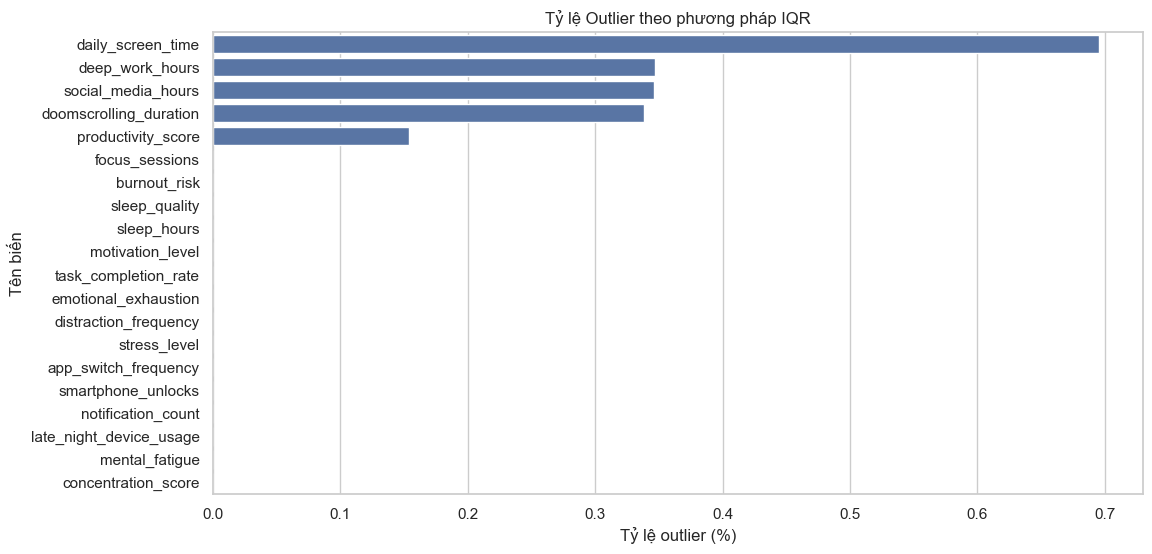

In [39]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=outlier_report_df,
    x="outlier_percent",
    y="column_name"
)

plt.title("Tỷ lệ Outlier theo phương pháp IQR")
plt.xlabel("Tỷ lệ outlier (%)")
plt.ylabel("Tên biến")
plt.show()

## Feature Selection

Ở bước này, notebook chỉ giữ lại các thuộc tính nghiên cứu đã được lựa chọn.

Lưu ý:
- Đây là bước chọn biến theo căn cứ học thuật.
- Không tạo biến mới.
- Không thực hiện Feature Engineering.

In [40]:
available_research_features = [
    col for col in research_features if col in df.columns
]

df_selected = df[available_research_features].copy()

print("Shape trước Feature Selection:", df.shape)
print("Shape sau Feature Selection:", df_selected.shape)

display(df_selected.head())

Shape trước Feature Selection: (5000000, 34)
Shape sau Feature Selection: (5000000, 22)


,emotional_exhaustion,stress_level,mental_fatigue,daily_screen_time,social_media_hours,doomscrolling_duration,late_night_device_usage,notification_count,smartphone_unlocks,app_switch_frequency,concentration_score,distraction_frequency,focus_sessions,deep_work_hours,task_completion_rate,motivation_level,sleep_hours,sleep_quality,work_mode,device_usage_type,burnout_risk,productivity_score
0,4,10,10,8.8,5.0,1.2,1,112,49,41,2,67,3,6.0,92,8.0,5.9,10,Office,Entertainment-Centric,46,100
1,9,5,7,10.3,2.2,2.4,1,168,153,119,3,75,9,4.6,74,5.0,5.6,7,Hybrid,Work-Centric,57,96
2,2,4,5,6.5,4.6,1.0,1,199,234,121,7,70,5,3.0,96,8.0,5.5,8,Remote,Balanced,29,79
3,5,1,4,9.6,1.2,0.1,1,122,177,85,3,107,9,2.9,60,6.0,6.1,5,Office,Balanced,57,63
4,9,4,7,13.3,1.6,1.9,1,73,91,221,9,72,9,2.8,73,4.0,7.9,1,Hybrid,Work-Centric,64,89


## Encoding

Hai biến phân loại được mã hóa:
- `work_mode`
- `device_usage_type`

Phương pháp sử dụng:
- One-Hot Encoding

Lý do:
- Hai biến này là biến phân loại không có thứ bậc tự nhiên rõ ràng.
- One-Hot Encoding giúp tránh việc mô hình hoặc phân tích sau này hiểu nhầm quan hệ thứ bậc giữa các nhóm.

In [41]:
encoding_columns = [
    col for col in target_categorical_columns
    if col in df_selected.columns
]

df_encoded = df_selected.copy()

if encoding_columns:
    encoder = OneHotEncoder(
        sparse_output=False,
        drop=None,
        handle_unknown="ignore"
    )
    
    encoded_array = encoder.fit_transform(df_encoded[encoding_columns])
    
    encoded_columns = encoder.get_feature_names_out(encoding_columns)
    
    df_encoded_part = pd.DataFrame(
        encoded_array,
        columns=encoded_columns,
        index=df_encoded.index
    )
    
    df_encoded = df_encoded.drop(columns=encoding_columns)
    df_encoded = pd.concat([df_encoded, df_encoded_part], axis=1)
    
    print("Các biến đã được encoding:")
    print(encoding_columns)
    print("\nCác cột sau encoding:")
    print(list(encoded_columns))
else:
    print("Không có biến phân loại cần encoding.")

display(df_encoded.head())

Các biến đã được encoding:
['work_mode', 'device_usage_type']

Các cột sau encoding:
['work_mode_Hybrid', 'work_mode_Office', 'work_mode_Remote', 'device_usage_type_Balanced', 'device_usage_type_Entertainment-Centric', 'device_usage_type_Work-Centric']


,emotional_exhaustion,stress_level,mental_fatigue,daily_screen_time,social_media_hours,doomscrolling_duration,late_night_device_usage,notification_count,smartphone_unlocks,app_switch_frequency,concentration_score,distraction_frequency,focus_sessions,deep_work_hours,task_completion_rate,motivation_level,sleep_hours,sleep_quality,burnout_risk,productivity_score,work_mode_Hybrid,work_mode_Office,work_mode_Remote,device_usage_type_Balanced,device_usage_type_Entertainment-Centric,device_usage_type_Work-Centric
0,4,10,10,8.8,5.0,1.2,1,112,49,41,2,67,3,6.0,92,8.0,5.9,10,46,100,0.0,1.0,0.0,0.0,1.0,0.0
1,9,5,7,10.3,2.2,2.4,1,168,153,119,3,75,9,4.6,74,5.0,5.6,7,57,96,1.0,0.0,0.0,0.0,0.0,1.0
2,2,4,5,6.5,4.6,1.0,1,199,234,121,7,70,5,3.0,96,8.0,5.5,8,29,79,0.0,0.0,1.0,1.0,0.0,0.0
3,5,1,4,9.6,1.2,0.1,1,122,177,85,3,107,9,2.9,60,6.0,6.1,5,57,63,0.0,1.0,0.0,1.0,0.0,0.0
4,9,4,7,13.3,1.6,1.9,1,73,91,221,9,72,9,2.8,73,4.0,7.9,1,64,89,1.0,0.0,0.0,0.0,0.0,1.0


## Scaling bằng StandardScaler

Các biến định lượng được chuẩn hóa bằng `StandardScaler`.

Công thức chuẩn hóa:

$$
z = \frac{x-\mu}{\sigma}
$$

Trong đó:

- $x$: giá trị ban đầu
- $\mu$: trung bình của biến
- $\sigma$: độ lệch chuẩn của biến

Mục tiêu:
- Đưa các biến định lượng về cùng thang đo.
- Hạn chế việc biến có đơn vị lớn chi phối các phân tích sau này.

In [42]:
scaling_columns = [
    col for col in target_numerical_columns
    if col in df_encoded.columns
]

scaler = StandardScaler()

df_processed = df_encoded.copy()
df_processed[scaling_columns] = scaler.fit_transform(df_processed[scaling_columns])

print("Số biến được scaling:", len(scaling_columns))
print("Các biến được scaling:")
print(scaling_columns)

display(df_processed.head())

scaling_check = df_processed[scaling_columns].agg(["mean", "std"]).T
scaling_check.columns = ["mean_after_scaling", "std_after_scaling"]

display(scaling_check.head(20))

Số biến được scaling: 20
Các biến được scaling:
['emotional_exhaustion', 'stress_level', 'mental_fatigue', 'daily_screen_time', 'social_media_hours', 'doomscrolling_duration', 'late_night_device_usage', 'notification_count', 'smartphone_unlocks', 'app_switch_frequency', 'concentration_score', 'distraction_frequency', 'focus_sessions', 'deep_work_hours', 'task_completion_rate', 'motivation_level', 'sleep_hours', 'sleep_quality', 'burnout_risk', 'productivity_score']


,emotional_exhaustion,stress_level,mental_fatigue,daily_screen_time,social_media_hours,doomscrolling_duration,late_night_device_usage,notification_count,smartphone_unlocks,app_switch_frequency,concentration_score,distraction_frequency,focus_sessions,deep_work_hours,task_completion_rate,motivation_level,sleep_hours,sleep_quality,burnout_risk,productivity_score,work_mode_Hybrid,work_mode_Office,work_mode_Remote,device_usage_type_Balanced,device_usage_type_Entertainment-Centric,device_usage_type_Work-Centric
0,-0.523017,1.567342,1.566996,0.320262,0.851270,-0.560537,0.73381,-0.888509,-1.313089,-1.277371,-1.219186,0.202808,-0.522331,1.736441,1.250066,0.882778,-0.411806,1.565948,-0.117060,1.328250,0.0,1.0,0.0,0.0,1.0,0.0
1,1.218038,-0.173951,0.522434,0.921511,-0.756306,0.499339,0.73381,-0.377861,-0.049138,-0.151528,-0.870970,0.435704,1.566280,0.916641,0.227411,-0.172107,-0.617485,0.521375,0.381309,1.142195,1.0,0.0,0.0,0.0,0.0,1.0
2,-1.219440,-0.522209,-0.173941,-0.601654,0.621617,-0.737183,0.73381,-0.095181,0.935287,-0.122661,0.521897,0.290144,0.173873,-0.020273,1.477323,0.882778,-0.686045,0.869566,-0.887265,0.351460,0.0,0.0,1.0,1.0,0.0,0.0
3,-0.174806,-1.566985,-0.522128,0.640928,-1.330440,-1.532090,0.73381,-0.797322,0.242544,-0.642280,-0.870970,1.367288,1.566280,-0.078830,-0.567988,0.179521,-0.274686,-0.175008,0.381309,-0.392761,0.0,1.0,0.0,1.0,0.0,0.0
4,1.218038,-0.522209,0.522434,2.124010,-1.100787,0.057724,0.73381,-1.244139,-0.802647,1.320727,1.218331,0.348368,1.566280,-0.137387,0.170597,-0.523735,0.959388,-1.567773,0.698452,0.816598,1.0,0.0,0.0,0.0,0.0,1.0


,mean_after_scaling,std_after_scaling
emotional_exhaustion,4.640128e-17,1.0
stress_level,-7.077290e-17,1.0
mental_fatigue,-2.643219e-18,1.0
daily_screen_time,2.504140e-15,1.0
social_media_hours,1.149189e-15,1.0
doomscrolling_duration,6.844729e-16,1.0
late_night_device_usage,-1.080842e-16,1.0
notification_count,2.047500e-17,1.0
smartphone_unlocks,-3.322924e-17,1.0
app_switch_frequency,8.866508e-17,1.0


## Validation After Processing

Sau khi hoàn tất cleaning và preprocessing, cần kiểm tra lại:
- Kích thước dataset.
- Missing values.
- Duplicate values.
- Kiểu dữ liệu.
- Một số dòng đầu tiên của dataset sau xử lý.

In [43]:
print("VALIDATION AFTER PROCESSING")
print("-" * 60)

print(f"Shape sau xử lý: {df_processed.shape}")
print(f"Tổng số missing values: {df_processed.isnull().sum().sum():,}")
print(f"Số dòng trùng lặp: {df_processed.duplicated().sum():,}")

print("-" * 60)

display(df_processed.head())

VALIDATION AFTER PROCESSING
------------------------------------------------------------
Shape sau xử lý: (5000000, 26)
Tổng số missing values: 0
Số dòng trùng lặp: 0
------------------------------------------------------------


,emotional_exhaustion,stress_level,mental_fatigue,daily_screen_time,social_media_hours,doomscrolling_duration,late_night_device_usage,notification_count,smartphone_unlocks,app_switch_frequency,concentration_score,distraction_frequency,focus_sessions,deep_work_hours,task_completion_rate,motivation_level,sleep_hours,sleep_quality,burnout_risk,productivity_score,work_mode_Hybrid,work_mode_Office,work_mode_Remote,device_usage_type_Balanced,device_usage_type_Entertainment-Centric,device_usage_type_Work-Centric
0,-0.523017,1.567342,1.566996,0.320262,0.851270,-0.560537,0.73381,-0.888509,-1.313089,-1.277371,-1.219186,0.202808,-0.522331,1.736441,1.250066,0.882778,-0.411806,1.565948,-0.117060,1.328250,0.0,1.0,0.0,0.0,1.0,0.0
1,1.218038,-0.173951,0.522434,0.921511,-0.756306,0.499339,0.73381,-0.377861,-0.049138,-0.151528,-0.870970,0.435704,1.566280,0.916641,0.227411,-0.172107,-0.617485,0.521375,0.381309,1.142195,1.0,0.0,0.0,0.0,0.0,1.0
2,-1.219440,-0.522209,-0.173941,-0.601654,0.621617,-0.737183,0.73381,-0.095181,0.935287,-0.122661,0.521897,0.290144,0.173873,-0.020273,1.477323,0.882778,-0.686045,0.869566,-0.887265,0.351460,0.0,0.0,1.0,1.0,0.0,0.0
3,-0.174806,-1.566985,-0.522128,0.640928,-1.330440,-1.532090,0.73381,-0.797322,0.242544,-0.642280,-0.870970,1.367288,1.566280,-0.078830,-0.567988,0.179521,-0.274686,-0.175008,0.381309,-0.392761,0.0,1.0,0.0,1.0,0.0,0.0
4,1.218038,-0.522209,0.522434,2.124010,-1.100787,0.057724,0.73381,-1.244139,-0.802647,1.320727,1.218331,0.348368,1.566280,-0.137387,0.170597,-0.523735,0.959388,-1.567773,0.698452,0.816598,1.0,0.0,0.0,0.0,0.0,1.0


In [44]:
processed_summary = pd.DataFrame({
    "column_name": df_processed.columns,
    "dtype": df_processed.dtypes.astype(str),
    "missing_count": df_processed.isnull().sum().values,
    "unique_values": df_processed.nunique().values
})

display(processed_summary)

,column_name,dtype,missing_count,unique_values
emotional_exhaustion,emotional_exhaustion,float64,0,10
stress_level,stress_level,float64,0,10
mental_fatigue,mental_fatigue,float64,0,10
daily_screen_time,daily_screen_time,float64,0,171
social_media_hours,social_media_hours,float64,0,121
doomscrolling_duration,doomscrolling_duration,float64,0,80
late_night_device_usage,late_night_device_usage,float64,0,2
notification_count,notification_count,float64,0,380
smartphone_unlocks,smartphone_unlocks,float64,0,285
app_switch_frequency,app_switch_frequency,float64,0,240


## Save Dataset

Dataset sau xử lý được lưu tại:

`data/processed/digital_burnout_processed.csv`


In [45]:
output_path = "../data/processed/digital_burnout_processed.csv"

df_processed.to_csv(
    output_path,
    index=False
)

print("Dataset đã được lưu thành công.")
print(f"Đường dẫn lưu file: {output_path}")

Dataset đã được lưu thành công.
Đường dẫn lưu file: ../data/processed/digital_burnout_processed.csv
